In [1]:
# Install required libraries
!pip install transformers datasets scikit-learn gensim nltk torch torchvision torchaudio --quiet
!pip install accelerate -U --quiet
print("✅ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 83.3 MB/s eta 0:00:00
✅ All packages installed successfully!


In [3]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import re

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter

# Dataset
from datasets import load_dataset

# Transformers (BERT)
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    Trainer, TrainingArguments
)

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Libraries loaded | Device: {device}")

✅ Libraries loaded | Device: cuda


In [4]:
import pandas as pd

# Load your downloaded Kaggle CSV
df = pd.read_csv('/content/IMDB Dataset.csv')  # ← adjust filename if different

# Map sentiment to numeric label
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Create train/test split manually (since no pre-split like HuggingFace)
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Total samples : {len(df)}")
print(f"Columns       : {list(df.columns)}")
df.head(3)

Total samples : 50000
Columns       : ['review', 'sentiment', 'label']


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


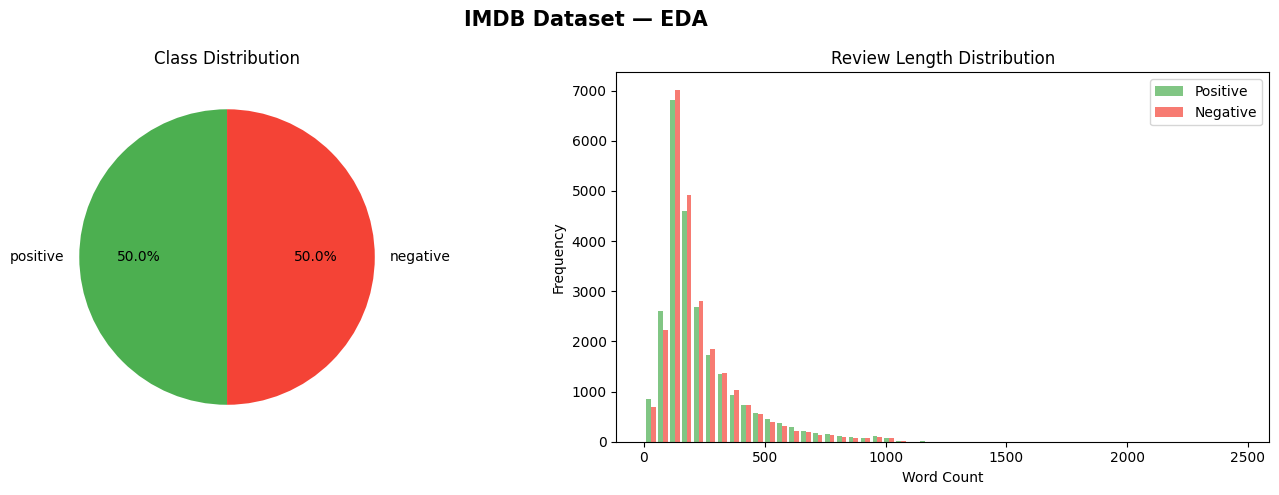

Average review length : 231 words
Max review length     : 2470 words


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('IMDB Dataset — EDA', fontsize=15, fontweight='bold')

# Class distribution
sentiment_counts = df['sentiment'].value_counts()
axes[0].pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90
)
axes[0].set_title('Class Distribution')

# Review length distribution
df['review_length'] = df['review'].apply(lambda x: len(x.split()))
axes[1].hist(
    [df[df['label']==1]['review_length'], df[df['label']==0]['review_length']],
    bins=50, label=['Positive', 'Negative'],
    color=['#4CAF50', '#F44336'], alpha=0.7
)
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average review length : {df['review_length'].mean():.0f} words")
print(f"Max review length     : {df['review_length'].max()} words")

In [6]:
stemmer   = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Full NLP pipeline: clean → tokenize → remove stopwords → stem."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # 4. Keep only alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 5. Tokenize
    tokens = word_tokenize(text)
    # 6. Remove stopwords + short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 7. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

print("Preprocessing text (this may take ~2 minutes)...")
df['clean_text'] = df['review'].apply(preprocess_text)

# Preview
print("\n--- Sample Preprocessing ---")
print("ORIGINAL :", df['review'].iloc[0][:200])
print("CLEANED  :", df['clean_text'].iloc[0][:200])
print("\n✅ Preprocessing complete!")

Preprocessing text (this may take ~2 minutes)...

--- Sample Preprocessing ---
ORIGINAL : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo
CLEANED  : one review mention watch episod hook right exactli happen first thing struck brutal unflinch scene violenc set right word trust show faint heart timid show pull punch regard drug sex violenc hardcor c

✅ Preprocessing complete!


In [7]:
# Train/test split
X = df['clean_text'].values
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),     # unigrams + bigrams
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Train shape : {X_train_tfidf.shape}")
print(f"Test shape  : {X_test_tfidf.shape}")
print("✅ TF-IDF features extracted!")

Train shape : (40000, 30000)
Test shape  : (10000, 30000)
✅ TF-IDF features extracted!



  Naive Bayes — Results
  Accuracy  : 0.8786
  Precision : 0.8693
  Recall    : 0.8912
  F1-Score  : 0.8801
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      5000
    Positive       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



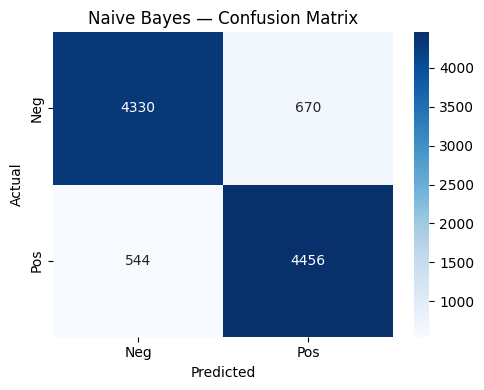

In [8]:
def evaluate_model(name, y_true, y_pred):
    """Print metrics and plot confusion matrix."""
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)

    print(f"\n{'='*45}")
    print(f"  {name} — Results")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {pre:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"{'='*45}")
    print(classification_report(y_true, y_pred, target_names=['Negative','Positive']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

    return {'Model': name, 'Accuracy': acc, 'Precision': pre, 'Recall': rec, 'F1': f1}

# Train Naive Bayes
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)

results = []
results.append(evaluate_model('Naive Bayes', y_test, nb_preds))

In [9]:
# ── Build Vocabulary ────────────────────────────────────────────────
MAX_VOCAB  = 20000
MAX_LEN    = 256
EMBED_DIM  = 128
HIDDEN_DIM = 128
BATCH_SIZE = 64
EPOCHS     = 5

# Use raw (non-stemmed) split for LSTM
X_raw = df['review'].apply(lambda x: re.sub(r'<.*?>', ' ', x.lower()))
X_raw = X_raw.apply(lambda x: re.sub(r'[^a-z\s]', ' ', x)).values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, df['label'].values, test_size=0.2, random_state=42, stratify=df['label'].values
)

# Vocabulary
all_tokens = ' '.join(X_train_raw).split()
vocab_counter = Counter(all_tokens)
vocab = ['<PAD>', '<UNK>'] + [w for w, _ in vocab_counter.most_common(MAX_VOCAB-2)]
word2idx = {w: i for i, w in enumerate(vocab)}

def encode(text, max_len=MAX_LEN):
    tokens = text.split()[:max_len]
    ids = [word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>
    return ids

print(f"Vocabulary size : {len(vocab)}")

# ── Dataset & DataLoader ─────────────────────────────────────────────
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = [torch.tensor(encode(t), dtype=torch.long) for t in texts]
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    return texts_padded, torch.stack(labels)

train_dataset = IMDBDataset(X_train_raw, y_train_raw)
test_dataset  = IMDBDataset(X_test_raw,  y_test_raw)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("✅ Dataset prepared!")

Vocabulary size : 20000
✅ Dataset prepared!


LSTM Model Parameters: 3,219,970
Epoch [1/5] | Loss: 0.6442 | Accuracy: 0.6247
Epoch [2/5] | Loss: 0.5510 | Accuracy: 0.7312
Epoch [3/5] | Loss: 0.4398 | Accuracy: 0.7997
Epoch [4/5] | Loss: 0.3866 | Accuracy: 0.8320
Epoch [5/5] | Loss: 0.3443 | Accuracy: 0.8499


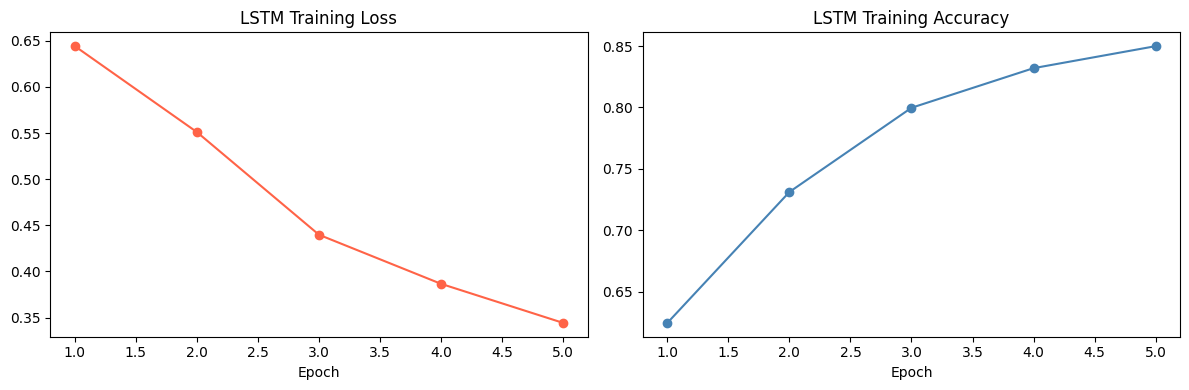

In [10]:
# ── LSTM Model Definition ────────────────────────────────────────────
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes=2, num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, (hn, _) = self.lstm(emb)
        # Concatenate final forward and backward hidden states
        hidden = torch.cat((hn[-2], hn[-1]), dim=1)
        return self.fc(self.dropout(hidden))

lstm_model = LSTMClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM).to(device)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion  = nn.CrossEntropyLoss()
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"LSTM Model Parameters: {total_params:,}")

# ── Training Loop ────────────────────────────────────────────────────
train_losses, train_accs = [], []

for epoch in range(EPOCHS):
    lstm_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, (texts, labels) in enumerate(train_loader):
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = lstm_model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    avg_acc  = correct / total
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)
    scheduler.step()
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.4f} | Accuracy: {avg_acc:.4f}")

# ── Plot Training Curves ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS+1), train_losses, marker='o', color='tomato')
axes[0].set_title('LSTM Training Loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(range(1, EPOCHS+1), train_accs, marker='o', color='steelblue')
axes[1].set_title('LSTM Training Accuracy'); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()


  LSTM — Results
  Accuracy  : 0.8528
  Precision : 0.8403
  Recall    : 0.8712
  F1-Score  : 0.8555
              precision    recall  f1-score   support

    Negative       0.87      0.83      0.85      5000
    Positive       0.84      0.87      0.86      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



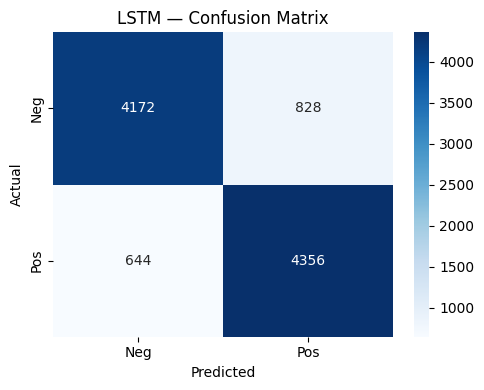

In [11]:
# ── Evaluate LSTM ────────────────────────────────────────────────────
lstm_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        outputs = lstm_model(texts)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

results.append(evaluate_model('LSTM', all_labels, all_preds))

In [12]:
from datasets import Dataset as HFDataset

# Use a small subset to keep training fast on free Colab
BERT_TRAIN_SAMPLES = 5000
BERT_TEST_SAMPLES  = 1000

bert_train_df = train_df.sample(BERT_TRAIN_SAMPLES, random_state=42).reset_index(drop=True).rename(columns={'review':'text'})
bert_test_df  = test_df.sample(BERT_TEST_SAMPLES,  random_state=42).reset_index(drop=True).rename(columns={'review':'text'})

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_fn(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

# Convert to HuggingFace datasets
hf_train = HFDataset.from_pandas(bert_train_df[['text', 'label']])
hf_test  = HFDataset.from_pandas(bert_test_df[['text', 'label']])

hf_train = hf_train.map(tokenize_fn, batched=True)
hf_test  = hf_test.map(tokenize_fn,  batched=True)

hf_train.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
hf_test.set_format( type='torch', columns=['input_ids', 'attention_mask', 'label'])

print(f"BERT train size : {len(hf_train)}")
print(f"BERT test size  : {len(hf_test)}")
print("✅ Tokenization complete!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

BERT train size : 5000
BERT test size  : 1000
✅ Tokenization complete!


In [13]:
from sklearn.metrics import accuracy_score
import numpy as np

# ── Load Pre-trained BERT ────────────────────────────────────────────
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy' : accuracy_score(labels, predictions),
        'f1'       : f1_score(labels, predictions),
        'precision': precision_score(labels, predictions),
        'recall'   : recall_score(labels, predictions)
    }

training_args = TrainingArguments(
    output_dir          = './bert_results',
    num_train_epochs    = 2,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_steps        = 100,
    weight_decay        = 0.01,
    logging_dir         = './bert_logs',
    logging_steps       = 50,
    eval_strategy       = 'epoch',
    save_strategy       = 'epoch',
    load_best_model_at_end = True,
    report_to           = 'none'
)

trainer = Trainer(
    model           = bert_model,
    args            = training_args,
    train_dataset   = hf_train,
    eval_dataset    = hf_test,
    compute_metrics = compute_metrics,
)

print("Training BERT (this may take 15–25 minutes on T4 GPU)...")
trainer.train()
print("✅ BERT training complete!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Training BERT (this may take 15–25 minutes on T4 GPU)...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.329518,0.252105,0.894000,0.898467,0.879925,0.917808
2,0.207261,0.343020,0.889000,0.893372,0.877358,0.909980


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

✅ BERT training complete!


In [14]:
# ============================================================
# 🎬 STEP 12 — Interactive Sentiment Analyzer (run this cell)
# ============================================================
import ipywidgets as widgets
from IPython.display import display, HTML
import time

# ── Styled Header ────────────────────────────────────────────
display(HTML("""
<style>
  @import url('https://fonts.googleapis.com/css2?family=Syne:wght@700;800&family=DM+Sans:wght@300;400;500&display=swap');

  .sa-wrap {
    font-family: 'DM Sans', sans-serif;
    background: #0d0d0d;
    border: 1px solid #2a2a2a;
    border-radius: 16px;
    padding: 28px 32px;
    max-width: 720px;
    margin: 12px auto;
    box-shadow: 0 0 40px rgba(255,200,0,0.06);
  }
  .sa-title {
    font-family: 'Syne', sans-serif;
    font-size: 26px;
    font-weight: 800;
    color: #f5c518;
    letter-spacing: -0.5px;
    margin: 0 0 4px 0;
  }
  .sa-subtitle {
    color: #666;
    font-size: 13px;
    margin-bottom: 20px;
  }
  .sa-result-box {
    background: #161616;
    border-radius: 12px;
    padding: 20px 24px;
    margin-top: 18px;
    border: 1px solid #2a2a2a;
  }
  .sa-model-row {
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 10px 0;
    border-bottom: 1px solid #222;
  }
  .sa-model-row:last-child { border-bottom: none; }
  .sa-model-name {
    font-size: 13px;
    font-weight: 500;
    color: #aaa;
    width: 120px;
  }
  .sa-badge-pos {
    background: #0f2e1a;
    color: #3ddc84;
    border: 1px solid #1e6640;
    padding: 3px 14px;
    border-radius: 20px;
    font-size: 12px;
    font-weight: 600;
    letter-spacing: 0.5px;
  }
  .sa-badge-neg {
    background: #2e0f0f;
    color: #ff6b6b;
    border: 1px solid #661e1e;
    padding: 3px 14px;
    border-radius: 20px;
    font-size: 12px;
    font-weight: 600;
    letter-spacing: 0.5px;
  }
  .sa-conf {
    font-size: 12px;
    color: #555;
    width: 80px;
    text-align: right;
  }
  .sa-conf span {
    color: #888;
    font-weight: 500;
  }
  .sa-bar-wrap {
    flex: 1;
    margin: 0 16px;
    background: #222;
    border-radius: 4px;
    height: 5px;
    overflow: hidden;
  }
  .sa-bar-fill {
    height: 100%;
    border-radius: 4px;
    transition: width 0.6s ease;
  }
  .sa-verdict {
    text-align: center;
    font-family: 'Syne', sans-serif;
    font-size: 20px;
    font-weight: 800;
    margin-bottom: 16px;
    padding-bottom: 14px;
    border-bottom: 1px solid #2a2a2a;
  }
  .sa-error { color: #ff6b6b; font-size: 13px; padding: 10px 0; }
</style>

<div class="sa-wrap">
  <div class="sa-title">🎬 Sentiment Analyzer</div>
  <div class="sa-subtitle">IMDB Movie Review · Naive Bayes · LSTM · BERT</div>
</div>
"""))

# ── Widgets ──────────────────────────────────────────────────
review_box = widgets.Textarea(
    placeholder='Paste or type a movie review here...',
    layout=widgets.Layout(width='680px', height='110px',
                          border='1px solid #333',
                          border_radius='10px')
)
review_box.style.font_size = '14px'

analyze_btn = widgets.Button(
    description='  Analyze  ',
    button_style='',
    layout=widgets.Layout(width='140px', height='40px')
)
analyze_btn.style.button_color = '#f5c518'
analyze_btn.style.font_weight  = 'bold'

clear_btn = widgets.Button(
    description='Clear',
    button_style='',
    layout=widgets.Layout(width='90px', height='40px')
)
clear_btn.style.button_color = '#e3f2fd'   # light blue

status_lbl = widgets.Label(value='')
output_area = widgets.Output()

# ── Quick example buttons ─────────────────────────────────────
ex_pos = widgets.Button(description='😊 Positive example', layout=widgets.Layout(width='190px', height='32px'))
ex_neg = widgets.Button(description='😞 Negative example', layout=widgets.Layout(width='190px', height='32px'))
ex_pos.style.button_color = '#d4f8d4'   # light green
ex_neg.style.button_color = '#f8d4d4'   # light red/pink

POS_EXAMPLE = "An absolute masterpiece! The performances were stunning, the screenplay was tight and emotional, and the direction was flawless. One of the best films I've seen in years."
NEG_EXAMPLE = "Complete waste of time. The plot made no sense, the characters were flat, and the pacing was unbearably slow. I walked out halfway through."

def load_pos(b): review_box.value = POS_EXAMPLE
def load_neg(b): review_box.value = NEG_EXAMPLE
ex_pos.on_click(load_pos)
ex_neg.on_click(load_neg)

# ── Core prediction ──────────────────────────────────────────
def run_analysis(b):
    text = review_box.value.strip()
    output_area.clear_output()

    if not text:
        with output_area:
            display(HTML('<p class="sa-error">⚠️ Please enter a review first.</p>'))
        return

    status_lbl.value = '⏳ Analyzing...'
    analyze_btn.disabled = True

    predictions = {}

    try:
        # 1. Naive Bayes
        cleaned    = preprocess_text(text)
        tfidf_feat = tfidf.transform([cleaned])
        nb_pred    = nb.predict(tfidf_feat)[0]
        nb_conf    = nb.predict_proba(tfidf_feat).max()
        predictions['Naive Bayes'] = (nb_pred, nb_conf)

        # 2. LSTM
        lstm_model.eval()
        encoded = torch.tensor([encode(text.lower())], dtype=torch.long).to(device)
        with torch.no_grad():
            out = lstm_model(encoded)
            probs = torch.softmax(out, dim=1)
            predictions['LSTM'] = (out.argmax(dim=1).item(), probs.max().item())

        # 3. BERT
        bert_model.eval()
        inputs = tokenizer(text, return_tensors='pt', truncation=True,
                           max_length=256, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = bert_model(**inputs).logits
            probs  = torch.softmax(logits, dim=1)
            predictions['BERT'] = (logits.argmax(dim=1).item(), probs.max().item())

    except Exception as e:
        with output_area:
            display(HTML(f'<p class="sa-error">❌ Error: {e}</p>'))
        status_lbl.value = ''
        analyze_btn.disabled = False
        return

    # ── Verdict (majority vote) ───────────────────────────────
    votes     = [v[0] for v in predictions.values()]
    majority  = 1 if votes.count(1) >= 2 else 0
    avg_conf  = sum(v[1] for v in predictions.values()) / len(predictions)

    if majority == 1:
        verdict_html = '<div class="sa-verdict" style="color:#3ddc84;">✅ POSITIVE SENTIMENT</div>'
    else:
        verdict_html = '<div class="sa-verdict" style="color:#ff6b6b;">❌ NEGATIVE SENTIMENT</div>'

    # ── Build result rows ─────────────────────────────────────
    rows_html = ''
    for model_name, (pred, conf) in predictions.items():
        label   = 'POSITIVE' if pred == 1 else 'NEGATIVE'
        badge   = f'<span class="sa-badge-pos">{label}</span>' if pred == 1 else f'<span class="sa-badge-neg">{label}</span>'
        bar_col = '#3ddc84' if pred == 1 else '#ff6b6b'
        bar_w   = int(conf * 100)
        rows_html += f"""
        <div class="sa-model-row">
          <span class="sa-model-name">{model_name}</span>
          {badge}
          <div class="sa-bar-wrap">
            <div class="sa-bar-fill" style="width:{bar_w}%;background:{bar_col};"></div>
          </div>
          <span class="sa-conf">conf <span>{conf:.0%}</span></span>
        </div>"""

    html = f"""
    <div class="sa-wrap">
      <div class="sa-result-box">
        {verdict_html}
        {rows_html}
      </div>
      <p style="color:#444;font-size:11px;margin-top:12px;text-align:right;">
        Avg confidence: {avg_conf:.0%} · {len(text.split())} words analyzed
      </p>
    </div>"""

    with output_area:
        display(HTML(html))

    status_lbl.value = '✅ Done'
    analyze_btn.disabled = False

def clear_all(b):
    review_box.value = ''
    output_area.clear_output()
    status_lbl.value = ''

analyze_btn.on_click(run_analysis)
clear_btn.on_click(clear_all)

# ── Layout ────────────────────────────────────────────────────
display(widgets.VBox([
    review_box,
    widgets.HBox([analyze_btn, clear_btn, status_lbl],
                 layout=widgets.Layout(align_items='center', gap='10px')),
    widgets.HBox([ex_pos, ex_neg],
                 layout=widgets.Layout(gap='8px', margin='4px 0 0 0')),
    output_area
]))